<a href="https://colab.research.google.com/github/meryramirez280600-svg/Dataset_to_streamlit/blob/main/Dataset_proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Calidad del Aire en Colombia (Promedio Anual)


###Carga de la data  y limpieza

In [1]:
#librerias de uso
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files

In [2]:
# ajusta la configracion de apnadas para ver los decimales en la pantalla
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
####Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
df_aire = pd.read_csv ('/content/drive/MyDrive/Colab Notebooks/Proyecto final/Calidad_del_Aire_en_Colombia_(Promedio_Anual)_20260529.csv')

Mounted at /content/drive


In [4]:
df_aire.sample(3)

,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Fechas/horas del máximo,Mínimo,Fechas/horas del mínimo,Días de excedencias,Código del Departamento,Nombre del Departamento,Código del Municipio,Nombre del Municipio,Tipo de Estación,Ubicacion
23046,"31,807",CAR,COLEGIO SOACHA,4.57,-74.20,PM2.5,ugm3,24,"2,020",19.1,...,12/12/2020 12:00,3.3,16/02/2020 12:00,33,25,CUNDINAMARCA,"25,754.00",SOACHA,Fija,POINT (-74.19548 4.573623)
3401,"9,023",AMVA,POLITÉCNICO JIC,6.21,-75.58,TAire10,Celsius,24,"2,015",23.1,...,27/06/2015 0:00,18.9,19/03/2015 0:00,0,5,ANTIOQUIA,"5,001.00",MEDELLÍN,Fija,POINT (-75.581111 6.211806)
19987,"9,019",CRC,EDIFICIO EDGAR NEGRET,2.45,-76.61,PM10,ugm3,24,"2,017",45.3,...,7/04/2017,17.4,26/03/2017,0,19,CAUCA,"19,001.00",POPAYÁN,Fija,POINT (-76.605444 2.445161)


In [5]:
## Imprimir el tipo de dato de cada columna y espacio en memoria que este ocupa
df_aire.info(memory_usage = "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29683 entries, 0 to 29682
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID Estacion                           29683 non-null  object 
 1   Autoridad Ambiental                   29683 non-null  object 
 2   Estación                              29683 non-null  object 
 3   Latitud                               29683 non-null  float64
 4   Longitud                              29683 non-null  float64
 5   Variable                              29683 non-null  object 
 6   Unidades                              29683 non-null  object 
 7   Tiempo de exposición (horas)          29683 non-null  int64  
 8   Año                                   29683 non-null  object 
 9   Promedio                              29683 non-null  object 
 10  Suma                                  29683 non-null  object 
 11  No. de datos   

In [6]:
#### Imprimir las columnas del dataset
df_aire.columns.tolist()

['ID Estacion',
 'Autoridad Ambiental',
 'Estación',
 'Latitud',
 'Longitud',
 'Variable',
 'Unidades',
 'Tiempo de exposición (horas)',
 'Año',
 'Promedio',
 'Suma',
 'No. de datos',
 'Representatividad Temporal',
 'Excedencias limite actual',
 'Porcentaje excedencias limite actual',
 'Mediana',
 'Percentil 98',
 'Máximo',
 'Fechas/horas del máximo',
 'Mínimo',
 'Fechas/horas del mínimo',
 'Días de excedencias',
 'Código del Departamento',
 'Nombre del Departamento',
 'Código del Municipio',
 'Nombre del Municipio',
 'Tipo de Estación',
 'Ubicacion']

In [7]:
## Remplazar , por
for col in df_aire.select_dtypes(include="object").columns:
    df_aire[col] = df_aire[col].str.replace(",", "", regex=False)

In [8]:
## Convertir columnas a string
columnas_string= ["Autoridad Ambiental", "Estación", "Variable", "Unidades", "Nombre del Municipio", "Tipo de Estación", "Nombre del Departamento", "Fechas/horas del máximo", "Fechas/horas del mínimo"]
for col in columnas_string:
    df_aire[col] = df_aire[col].astype("string")

In [9]:
## Convertir columnas a float
columnas_float=["ID Estacion","Promedio", "Suma","Mediana", "Percentil 98","Máximo", "Mínimo"]
for col in columnas_float:
    df_aire[col] = df_aire[col].astype(float)

In [10]:
## Convertir columnas a int
columnas_int= ["Año", "No. de datos"]
for col in columnas_int:
    df_aire[col] = df_aire[col].astype(int)

In [11]:
#convierte columna de fecha de object a tipo datatime
def parse_date_safe(date_str):
    # Si el valor ya es NaT o vacío, devolver NaT
    if pd.isna(date_str) or str(date_str).lower() == 'nan' or str(date_str).strip() == '':
        return pd.NaT

    cleaned_str = str(date_str).strip()

    # Primero, manejar múltiples fechas en la cadena, tomando solo la primera parte
    # Esto asume que si hay múltiples fechas separadas por ' - ' o ' ; ', solo la primera es relevante para la columna
    if ' - ' in cleaned_str:
        cleaned_str = cleaned_str.split(' - ')[0].strip()
    elif ' ; ' in cleaned_str:
        cleaned_str = cleaned_str.split(' ; ')[0].strip()

    # Intentar convertir como número de serie de fecha de Excel (cadenas numéricas)
    try:
        num_val = float(cleaned_str)
        # Rango razonable para números de serie de Excel para evitar convertir números no relacionados
        if num_val > 1 and num_val < 100000: # Excel dates are typically positive and within this range
            return pd.to_datetime(num_val, unit='D', origin='1899-12-30') # Fecha base de Excel
    except ValueError:
        pass # No es un número, continuar con el análisis de cadenas

    # Intentar analizar como cadena de fecha, priorizando el formato día/mes/año
    # Usamos infer_datetime_format=True para ayudar a detectar formatos y dayfirst=True para nuestro caso
    try:
        return pd.to_datetime(cleaned_str, infer_datetime_format=True, dayfirst=True, errors='raise')
    except Exception:
        pass # Falló el análisis, continuar con el siguiente intento

    # Último intento con inferencia de formato general sin dayfirst explícito, si aún falla
    try:
        return pd.to_datetime(cleaned_str, infer_datetime_format=True, errors='raise')
    except Exception:
        pass

    # Si todos los intentos fallan, devuelve NaT. Esto solo debería ocurrir si la cadena es verdaderamente imposible de parsear como fecha.
    return pd.NaT

In [12]:
date_columns_to_convert = ['Fechas/horas del máximo', 'Fechas/horas del mínimo']

for col in date_columns_to_convert:
    # Aplicar la función de análisis seguro a la columna
    df_aire[col] = df_aire[col].apply(parse_date_safe)

    # Asegurarse de que el tipo de datos de la columna sea datetime64[ns]
    # Y coercionar cualquier NaT que pudiera haberse generado (lo cual esperamos evitar)
    df_aire[col] = pd.to_datetime(df_aire[col], errors='coerce')


print("Información del DataFrame después de la conversión robusta de fechas:")
df_aire.info()

print("\nRecuento de valores nulos después de la conversión de fechas:")
display(df_aire[date_columns_to_convert].isnull().sum())

print("\nPrimeras 5 filas con las columnas de fecha convertidas:")
display(df_aire[date_columns_to_convert].head())

/tmp/ipykernel_8592/209360786.py:28: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(cleaned_str, infer_datetime_format=True, dayfirst=True, errors='raise')
/tmp/ipykernel_8592/209360786.py:28: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(cleaned_str, infer_datetime_format=True, dayfirst=True, errors='raise')
/tmp/ipykernel_8592/209360786.py:28: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(cleaned_str, infer_datetime_format=True, dayfirst=True, errors='raise')
/tmp/ipykernel_8592/209360786.py:28

Información del DataFrame después de la conversión robusta de fechas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29683 entries, 0 to 29682
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   ID Estacion                           29683 non-null  float64       
 1   Autoridad Ambiental                   29683 non-null  string        
 2   Estación                              29683 non-null  string        
 3   Latitud                               29683 non-null  float64       
 4   Longitud                              29683 non-null  float64       
 5   Variable                              29683 non-null  string        
 6   Unidades                              29683 non-null  string        
 7   Tiempo de exposición (horas)          29683 non-null  int64         
 8   Año                                   29683 non-null  int64         
 9   Pr

,0
Fechas/horas del máximo,0
Fechas/horas del mínimo,0



Primeras 5 filas con las columnas de fecha convertidas:


,Fechas/horas del máximo,Fechas/horas del mínimo
0,2011-11-29 01:00:00,2011-11-29 07:00:00
1,2011-11-16 00:00:00,2011-11-08 00:00:00
2,2011-12-20 02:00:00,2011-11-07 23:00:00
3,2011-09-12 10:00:00,2011-10-27 17:00:00
4,2011-10-20 00:00:00,2011-10-27 00:00:00


In [13]:
# ver loas tipos de datos que tengo
df_aire.dtypes

,0
ID Estacion,float64
Autoridad Ambiental,string[python]
Estación,string[python]
Latitud,float64
Longitud,float64
Variable,string[python]
Unidades,string[python]
Tiempo de exposición (horas),int64
Año,int64
Promedio,float64


In [14]:
## Eliminar columna
df_aire = df_aire.drop(['Ubicacion', 'Código del Departamento','Código del Municipio'],axis=1)
df_aire.head(3)

,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Mediana,Percentil 98,Máximo,Fechas/horas del máximo,Mínimo,Fechas/horas del mínimo,Días de excedencias,Nombre del Departamento,Nombre del Municipio,Tipo de Estación
0,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,DViento,deg,1,2011,256.80,...,244.20,350.80,359.50,2011-11-29 01:00:00,1.30,2011-11-29 07:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
1,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,DViento,deg,24,2011,257.40,...,257.90,304.20,336.80,2011-11-16 00:00:00,99.70,2011-11-08 00:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
2,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,PLiquida,mm,1,2011,4.00,...,2.80,12.80,23.00,2011-12-20 02:00:00,1.50,2011-11-07 23:00:00,0,ANTIOQUIA,GIRARDOTA,Fija


In [15]:
# hace un conteo de los valores nulos en la data
df_aire.isnull().sum()

,0
ID Estacion,0
Autoridad Ambiental,0
Estación,0
Latitud,0
Longitud,0
Variable,0
Unidades,0
Tiempo de exposición (horas),0
Año,0
Promedio,0


In [16]:
#elimina los valores nulos que se presentan en estas dos columnas
df_aire = df_aire.dropna(subset=[
    'Representatividad Temporal',
    'Tipo de Estación'
])

In [17]:
# vuelve los nombres del departamento en mayuscula y filtra la data para solo quedar con
#el departamento de antioquia
#departamento=['Antioquia','ANTIOQUIA']
filas_antes = len(df_aire)
df_aire['Nombre del Departamento'] = df_aire['Nombre del Departamento'].str.upper()
df_aire = df_aire[df_aire['Nombre del Departamento'] == 'ANTIOQUIA'].copy()
#df_aire = df_aire[df_aire['Nombre del Departamento'].isin(departamento)].copy()
#muestra las filas antes y despues del filtro
print(f"Filas antes del filtro: {filas_antes}")
print(f"Filas después del filtro (Antioquia): {len(df_aire)}")
display(df_aire.head())

Filas antes del filtro: 29533
Filas después del filtro (Antioquia): 8768


,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Mediana,Percentil 98,Máximo,Fechas/horas del máximo,Mínimo,Fechas/horas del mínimo,Días de excedencias,Nombre del Departamento,Nombre del Municipio,Tipo de Estación
0,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,DViento,deg,1,2011,256.80,...,244.20,350.80,359.50,2011-11-29 01:00:00,1.30,2011-11-29 07:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
1,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,DViento,deg,24,2011,257.40,...,257.90,304.20,336.80,2011-11-16 00:00:00,99.70,2011-11-08 00:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
2,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,PLiquida,mm,1,2011,4.00,...,2.80,12.80,23.00,2011-12-20 02:00:00,1.50,2011-11-07 23:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
3,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,P,mmHg,1,2011,645.90,...,646.10,648.10,649.80,2011-09-12 10:00:00,641.60,2011-10-27 17:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
4,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,P,mmHg,24,2011,645.90,...,645.90,647.20,647.90,2011-10-20 00:00:00,644.00,2011-10-27 00:00:00,0,ANTIOQUIA,GIRARDOTA,Fija


In [18]:
# ver los nombres de los municpios de antioquia que tenemos en la data
display(df_aire['Nombre del Municipio'].unique())

<StringArray>
[         'GIRARDOTA',             'ITAGÜÍ',           'SABANETA',
           'MEDELLÍN',              'AMAGÁ',            'BARBOSA',
              'BELLO',         'COPACABANA',           'HISPANIA',
       'SAN JERÓNIMO',
 ...
          'Marinilla',           'Rionegro',           'Medellín',
             'Itagüí',              'Yondó',              'Amagá',
 'Santa Rosa De Osos',            'La Ceja',             'Sonsón',
            'Guatapé']
Length: 126, dtype: string

In [19]:
#vuelve todos los nombres en mayuscula y hace un filtro para solo tener los municipios del valle del aburra
filas_antes = len(df_aire)
df_aire['Nombre del Municipio'] = df_aire['Nombre del Municipio'].str.upper()
municipios_seleccionados = ['BARBOSA','GIRARDOTA','COPACABANA','BELLO','MEDELLÍN','ENVIGADO','ITAGÜÍ','SABANETA','LA ESTRELLA','CALDAS']

df_aire = df_aire[df_aire['Nombre del Municipio'].isin(municipios_seleccionados)].copy()
#muestra la cantidad e filas que se tiene antes y despues de este filtro
print(f"Filas antes del filtro: {filas_antes}")
print(f"Filas después del filtro por municipios (Antioquia - Municipios Seleccionados): {len(df_aire)}")
display(df_aire.head())

Filas antes del filtro: 8768
Filas después del filtro por municipios (Antioquia - Municipios Seleccionados): 5681


,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Mediana,Percentil 98,Máximo,Fechas/horas del máximo,Mínimo,Fechas/horas del mínimo,Días de excedencias,Nombre del Departamento,Nombre del Municipio,Tipo de Estación
0,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,DViento,deg,1,2011,256.80,...,244.20,350.80,359.50,2011-11-29 01:00:00,1.30,2011-11-29 07:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
1,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,DViento,deg,24,2011,257.40,...,257.90,304.20,336.80,2011-11-16 00:00:00,99.70,2011-11-08 00:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
2,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,PLiquida,mm,1,2011,4.00,...,2.80,12.80,23.00,2011-12-20 02:00:00,1.50,2011-11-07 23:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
3,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,P,mmHg,1,2011,645.90,...,646.10,648.10,649.80,2011-09-12 10:00:00,641.60,2011-10-27 17:00:00,0,ANTIOQUIA,GIRARDOTA,Fija
4,"9,020.00",AMVA,I.E. COL. COLOMBIA,6.38,-75.44,P,mmHg,24,2011,645.90,...,645.90,647.20,647.90,2011-10-20 00:00:00,644.00,2011-10-27 00:00:00,0,ANTIOQUIA,GIRARDOTA,Fija


In [20]:
# ver la cantidad de filas y columnas que tiene la data
df_aire.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5681 entries, 0 to 29672
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   ID Estacion                           5681 non-null   float64       
 1   Autoridad Ambiental                   5681 non-null   string        
 2   Estación                              5681 non-null   string        
 3   Latitud                               5681 non-null   float64       
 4   Longitud                              5681 non-null   float64       
 5   Variable                              5681 non-null   string        
 6   Unidades                              5681 non-null   string        
 7   Tiempo de exposición (horas)          5681 non-null   int64         
 8   Año                                   5681 non-null   int64         
 9   Promedio                              5681 non-null   float64       
 10  Suma

In [21]:
# ver la cantidad de duplicados presentes en la data
df_aire.duplicated().sum()

np.int64(2752)

In [22]:
# ver los registros de 20 valores duplicados para comparar la infromación y hacer validaciones
df_aire[df_aire.duplicated()].head(20)

,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Mediana,Percentil 98,Máximo,Fechas/horas del máximo,Mínimo,Fechas/horas del mínimo,Días de excedencias,Nombre del Departamento,Nombre del Municipio,Tipo de Estación
5722,"8,995.00",AMVA,MED-AGUINAGA,6.25,-75.57,PM10,ugm3,24,2011,43.50,...,44.70,85.70,119.80,2011-05-12 00:00:00,10.10,2011-07-17 00:00:00,1,ANTIOQUIA,MEDELLÍN,Fija
13089,"8,995.00",AMVA,MED-AGUINAGA,6.25,-75.57,PM2.5,ugm3,1,2011,34.70,...,28.50,109.80,427.70,2011-06-30 18:00:00,0.40,2011-03-04 19:00:00,0,ANTIOQUIA,MEDELLÍN,Fija
13090,"8,995.00",AMVA,MED-AGUINAGA,6.25,-75.57,PM2.5,ugm3,24,2011,34.70,...,31.10,92.70,109.00,2011-07-13 00:00:00,12.00,2011-04-22 00:00:00,20,ANTIOQUIA,MEDELLÍN,Fija
13110,"9,002.00",AMVA,ITA-DITAIRES,6.17,-75.63,DViento,deg,1,2011,239.00,...,229.20,326.80,358.40,2011-11-08 11:00:00,1.30,2011-12-27 20:00:00,0,ANTIOQUIA,ITAGÜÍ,Fija
13200,"9,002.00",AMVA,ITA-DITAIRES,6.17,-75.63,DViento,deg,24,2011,239.40,...,243.00,301.90,328.10,2011-12-23 00:00:00,137.50,2011-12-30 00:00:00,0,ANTIOQUIA,ITAGÜÍ,Fija
13201,"9,002.00",AMVA,ITA-DITAIRES,6.17,-75.63,HAire2,perc,1,2011,74.40,...,79.30,90.40,91.20,2011-12-07 06:00:00,26.10,2011-12-22 17:00:00,0,ANTIOQUIA,ITAGÜÍ,Fija
13220,"9,002.00",AMVA,ITA-DITAIRES,6.17,-75.63,HAire2,perc,24,2011,74.50,...,74.60,82.20,83.90,2011-12-05 00:00:00,59.40,2011-12-22 00:00:00,0,ANTIOQUIA,ITAGÜÍ,Fija
13237,"9,002.00",AMVA,ITA-DITAIRES,6.17,-75.63,O3,ugm3,1,2011,24.90,...,11.10,109.60,186.70,2011-01-22 16:00:00,0.00,2011-05-26 08:00:00,42,ANTIOQUIA,ITAGÜÍ,Fija
13251,"9,002.00",AMVA,ITA-DITAIRES,6.17,-75.63,O3,ugm3,8,2011,24.50,...,16.70,80.50,126.50,2011-01-22 18:00:00,0.00,2011-05-01 07:00:00,34,ANTIOQUIA,ITAGÜÍ,Fija
13392,"9,002.00",AMVA,ITA-DITAIRES,6.17,-75.63,PLiquida,mm,1,2011,2.00,...,1.60,3.60,3.80,2011-12-11 17:00:00,1.10,2011-11-17 18:00:00,0,ANTIOQUIA,ITAGÜÍ,Fija


In [23]:
# crear una data para que sea la cual se va a usar para hacer grafricos y demas
df_aire.to_csv("Datesetlimpio_uso.csv", index=False)

In [24]:
files.download('Datesetlimpio_uso.csv')
print("¡Archivo descargado con éxito como 'Datasetlimpio_uso.csv'!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

¡Archivo descargado con éxito como 'Datasetlimpio_uso.csv'!


In [25]:
# cargar la data limpia
from google.colab import drive
drive.mount('/content/drive')
df_aire = pd.read_csv ('/content/drive/MyDrive/Colab Notebooks/Proyecto final/Datesetlimpio_uso.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
#muestra la fecha minima de los datos
df_aire["Fechas/horas del máximo"].min()

'2011-01-03 00:00:00.000000000'

In [29]:
# muesta la fecha maxima de los datos
df_aire["Fechas/horas del máximo"].max()

'2024-12-30 15:00:00.000000000'

###Resultados Estadísticos

In [30]:
# ver los datos estadisticos de las columnas
df_aire.describe()

,ID Estacion,Latitud,Longitud,Tiempo de exposición (horas),Año,Promedio,Suma,No. de datos,Representatividad Temporal,Excedencias limite actual,Porcentaje excedencias limite actual,Mediana,Percentil 98,Máximo,Mínimo,Días de excedencias
count,"5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00","5,681.00"
mean,"30,184.27",6.25,-75.56,12.59,"2,016.63",111.64,"437,752.01","3,271.77",69.10,21.53,0.58,104.16,189.43,242.32,58.60,5.87
std,"19,793.33",0.09,0.07,11.28,3.34,227.73,"1,420,781.09","3,594.90",33.16,110.03,2.27,222.72,373.28,565.46,167.12,23.23
min,"8,995.00",6.04,-75.67,1.00,"2,011.00",0.10,0.67,1.00,0.00,0.00,0.00,0.00,0.30,0.30,-35.70,0.00
25%,"29,493.00",6.17,-75.62,1.00,"2,014.00",18.70,"4,451.68",275.00,42.00,0.00,0.00,14.80,28.20,32.10,0.30,0.00
50%,"29,511.00",6.23,-75.58,8.00,"2,017.00",32.60,"27,203.00",365.00,86.00,0.00,0.00,26.10,72.60,90.80,6.20,0.00
75%,"30,856.00",6.33,-75.52,24.00,"2,019.00",75.10,"217,904.13","7,726.00",96.00,0.00,0.00,73.10,158.00,259.00,20.10,0.00
max,"99,999.00",6.44,-75.33,24.00,"2,024.00","1,965.70","16,066,368.14","8,783.00",167.00,"1,977.00",45.26,"2,204.10","4,467.90","8,362.90","1,170.70",280.00


In [31]:
## Frecuencias absoluta
col_strin= ["Autoridad Ambiental", "Estación", "Variable", "Unidades", "Nombre del Departamento", "Nombre del Municipio", "Tipo de Estación"]
for col in col_strin:
    print(df_aire[col].value_counts())

Autoridad Ambiental
AMVA            4867
CORANTIOQUIA     814
Name: count, dtype: int64
Estación
U. SAN BUENAVENTURA           364
I.E. CONCEJO MUNICIPAL        315
CORPORACIÓN LASALLISTA        314
POLITÉCNICO JIC               300
U. NAL - NÚCLEO EL VOLADOR    284
                             ... 
PARQUE LAS AGUAS*               1
ESCUELA JOAQUÍN A. (S)*         1
MARIA GORETTI*                  1
HOSPITAL STA. MARG.*            1
I.E. JORGE ELIECER G.*          1
Name: count, Length: 117, dtype: int64
Variable
PM2.5       711
PM10        615
VViento     556
DViento     530
RGlobal     386
HAire10     382
TAire10     376
P           372
PLiquida    352
O3          325
NO2         236
TAire2      232
HAire2      222
NO          146
CO          100
TAire        48
SO2          48
HAire        24
PST          20
Name: count, dtype: int64
Unidades
ugm3       2201
Celsius     656
perc        628
ms          556
deg         530
Wm2         386
mmHg        372
mm          352
Name: count, d

In [32]:
## Frecuencia relativa
col_strin= ["Autoridad Ambiental", "Estación", "Variable", "Unidades", "Nombre del Departamento", "Nombre del Municipio", "Tipo de Estación"]
for col in col_strin:
    print(df_aire[col].value_counts(normalize=True))

Autoridad Ambiental
AMVA           0.86
CORANTIOQUIA   0.14
Name: proportion, dtype: float64
Estación
U. SAN BUENAVENTURA          0.06
I.E. CONCEJO MUNICIPAL       0.06
CORPORACIÓN LASALLISTA       0.06
POLITÉCNICO JIC              0.05
U. NAL - NÚCLEO EL VOLADOR   0.05
                             ... 
PARQUE LAS AGUAS*            0.00
ESCUELA JOAQUÍN A. (S)*      0.00
MARIA GORETTI*               0.00
HOSPITAL STA. MARG.*         0.00
I.E. JORGE ELIECER G.*       0.00
Name: proportion, Length: 117, dtype: float64
Variable
PM2.5      0.13
PM10       0.11
VViento    0.10
DViento    0.09
RGlobal    0.07
HAire10    0.07
TAire10    0.07
P          0.07
PLiquida   0.06
O3         0.06
NO2        0.04
TAire2     0.04
HAire2     0.04
NO         0.03
CO         0.02
TAire      0.01
SO2        0.01
HAire      0.00
PST        0.00
Name: proportion, dtype: float64
Unidades
ugm3      0.39
Celsius   0.12
perc      0.11
ms        0.10
deg       0.09
Wm2       0.07
mmHg      0.07
mm        0.06
Nam

In [33]:
## Valores unicos de cada columna categoricas de la lista
col_strin= ["Autoridad Ambiental", "Estación", "Variable", "Unidades", "Nombre del Departamento", "Nombre del Municipio", "Tipo de Estación"]
print("Conteo de Valores Únicos por Columna")
for col in col_strin:
    print(f"Columna: {col:<25} -> {df_aire[col].nunique()} valores únicos")

Conteo de Valores Únicos por Columna
Columna: Autoridad Ambiental       -> 2 valores únicos
Columna: Estación                  -> 117 valores únicos
Columna: Variable                  -> 19 valores únicos
Columna: Unidades                  -> 8 valores únicos
Columna: Nombre del Departamento   -> 1 valores únicos
Columna: Nombre del Municipio      -> 10 valores únicos
Columna: Tipo de Estación          -> 2 valores únicos


In [34]:
## Medidas de tendencia central: Mean
df_aire.mean(numeric_only=True)

,0
ID Estacion,"30,184.27"
Latitud,6.25
Longitud,-75.56
Tiempo de exposición (horas),12.59
Año,"2,016.63"
Promedio,111.64
Suma,"437,752.01"
No. de datos,"3,271.77"
Representatividad Temporal,69.10
Excedencias limite actual,21.53


In [35]:
## Medidas de tendencia central: median
df_aire.median(numeric_only=True)

,0
ID Estacion,"29,511.00"
Latitud,6.23
Longitud,-75.58
Tiempo de exposición (horas),8.00
Año,"2,017.00"
Promedio,32.60
Suma,"27,203.00"
No. de datos,365.00
Representatividad Temporal,86.00
Excedencias limite actual,0.00


In [36]:
## Medidas de tendencia central: mode
df_aire.mode(numeric_only=True)

,ID Estacion,Latitud,Longitud,Tiempo de exposición (horas),Año,Promedio,Suma,No. de datos,Representatividad Temporal,Excedencias limite actual,Porcentaje excedencias limite actual,Mediana,Percentil 98,Máximo,Mínimo,Días de excedencias
0,"29,502.00",6.21,-75.58,24.00,"2,018.00",0.10,105.02,363,99.00,0.00,0.00,0.00,2.40,360.00,0.00,0.00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# Calculamos la moda específica de la columna Promedio
# Usamos .iloc[0] porque si hay empate, elegimos la primera moda de la lista
moda_promedio = df_aire['Promedio'].mode().iloc[0]

print("MEDIDAS DE TENDENCIA CENTRAL ")
print(f"Media (Aritmética): {df_aire['Promedio'].mean():.2f}")
print(f"Mediana (Mitad):    {df_aire['Promedio'].median():.2f}")
print(f"Moda (Se repite):   {moda_promedio:.2f}")

MEDIDAS DE TENDENCIA CENTRAL 
Media (Aritmética): 111.64
Mediana (Mitad):    32.60
Moda (Se repite):   0.10


In [38]:
## Medidas de dispersión: var
df_aire.var(numeric_only=True)

,0
ID Estacion,"391,775,750.92"
Latitud,0.01
Longitud,0.01
Tiempo de exposición (horas),127.33
Año,11.15
Promedio,"51,861.12"
Suma,"2,018,618,893,307.00"
No. de datos,"12,923,276.87"
Representatividad Temporal,"1,099.47"
Excedencias limite actual,"12,105.82"


In [39]:
## Medidas de dispersión: Desviación estandar
df_aire.std(numeric_only=True)

,0
ID Estacion,"19,793.33"
Latitud,0.09
Longitud,0.07
Tiempo de exposición (horas),11.28
Año,3.34
Promedio,227.73
Suma,"1,420,781.09"
No. de datos,"3,594.90"
Representatividad Temporal,33.16
Excedencias limite actual,110.03


In [40]:
## Medidas de dispersión: rango
df_aire.max(numeric_only=True)- df_aire.min(numeric_only=True)

,0
ID Estacion,"91,004.00"
Latitud,0.39
Longitud,0.34
Tiempo de exposición (horas),23.00
Año,13.00
Promedio,"1,965.60"
Suma,"16,066,367.47"
No. de datos,"8,782.00"
Representatividad Temporal,167.00
Excedencias limite actual,"1,977.00"


###Visualizaciones

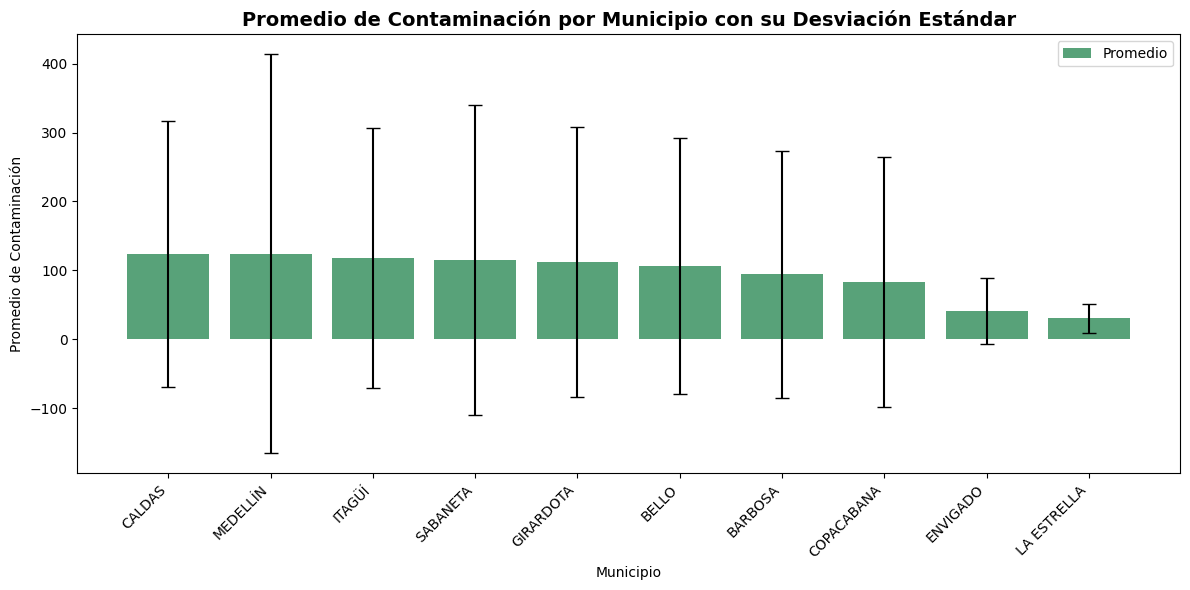

In [41]:
# Un Gráfico de Barras de Error (Error Bars),muestra el promedio de la contaminacion por cada municpio y la desviacion estandar
# Agrupamos por municipio y calculamos la media y la desviación estándar al tiempo
stats_municipio = df_aire.groupby('Nombre del Municipio')['Promedio'].agg(['mean', 'std']).dropna()

# Ordenamos por los más contaminados
stats_municipio = stats_municipio.sort_values(by='mean', ascending=False).head(10)

# Graficamos las barras del promedio, y con 'yerr' le pasamos la desviación estándar
plt.figure(figsize=(12, 6))
plt.bar(stats_municipio.index, stats_municipio['mean'],
        yerr=stats_municipio['std'], capsize=5, color='seagreen', alpha=0.8, label='Promedio')

plt.title('Promedio de Contaminación por Municipio con su Desviación Estándar', fontsize=14, fontweight='bold')
plt.xlabel('Municipio')
plt.ylabel('Promedio de Contaminación')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

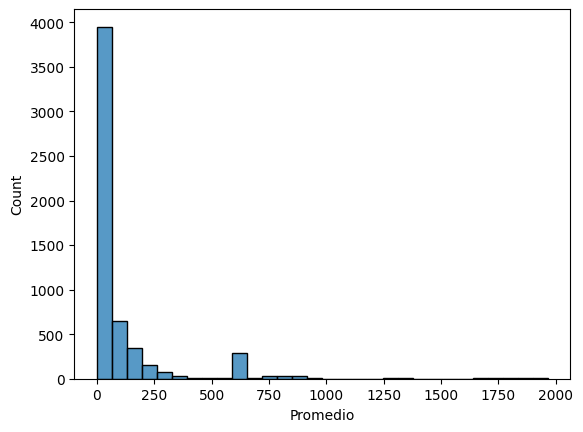

In [42]:
## Distribución de las variables ambientales: Para entender cómo se comportan los datos, histograma
sns.histplot(df_aire['Promedio'], bins=30)
plt.show()

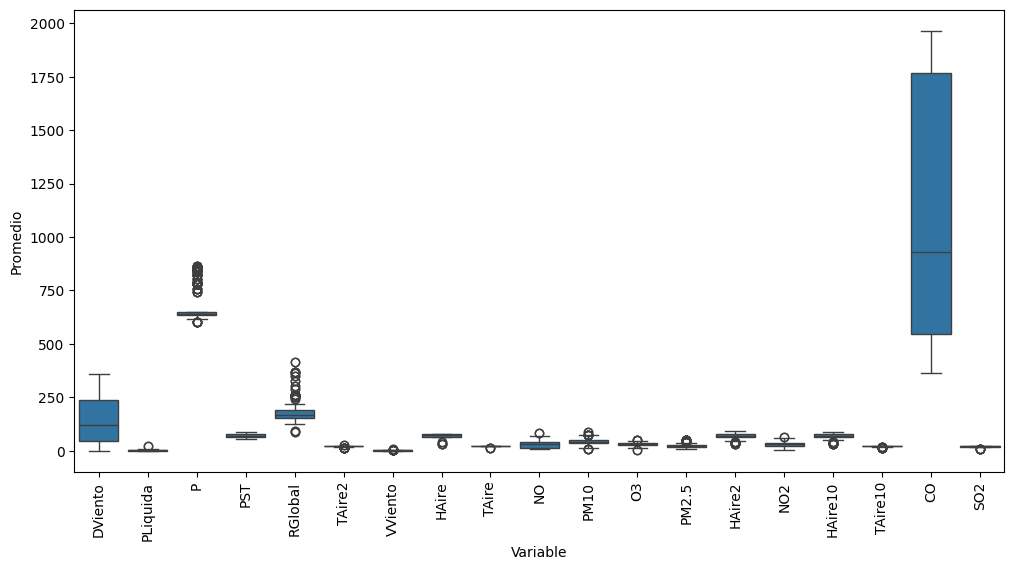

In [43]:
## Boxplot por variable: Compara la dispersión de cada contaminante o variable meteorológica
plt.figure(figsize=(12,6))
sns.boxplot(data=df_aire, x='Variable', y='Promedio')
plt.xticks(rotation=90)
plt.show()

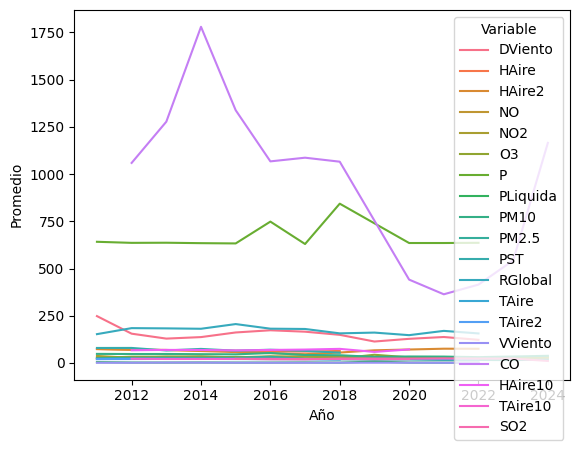

In [44]:
## Evolución temporal: Si quieres analizar tendencias ambientales
prom_anual = df_aire.groupby(['Año','Variable'])['Promedio'].mean().reset_index()

sns.lineplot(data=prom_anual,

             x='Año',
             y='Promedio',
             hue='Variable')
plt.show()

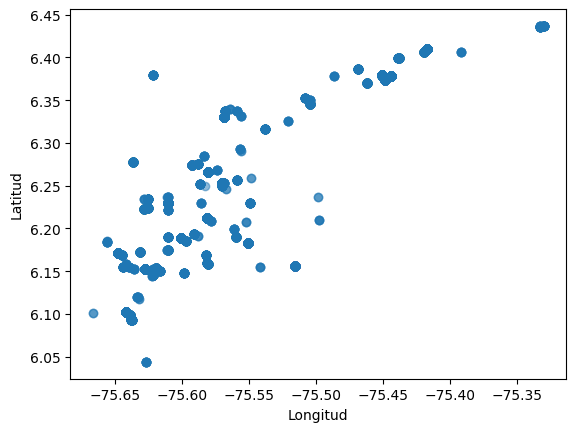

In [46]:
## crea grafico de dispersion apartir de cordenadas geográficas
plt.scatter(df_aire['Longitud'],
            df_aire['Latitud'],
            alpha=0.5)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

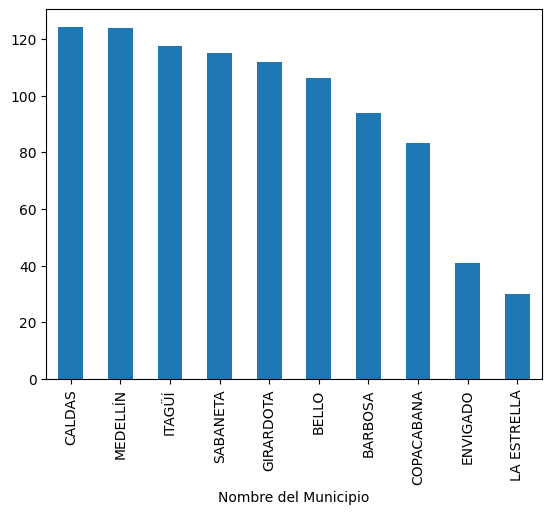

In [47]:
## Concentración promedio por municipio, grafico de barras
top = (df_aire.groupby('Nombre del Municipio')['Promedio']
         .mean()
         .sort_values(ascending=False)
         .head(15))

top.plot(kind='bar')
plt.show()

<Axes: >

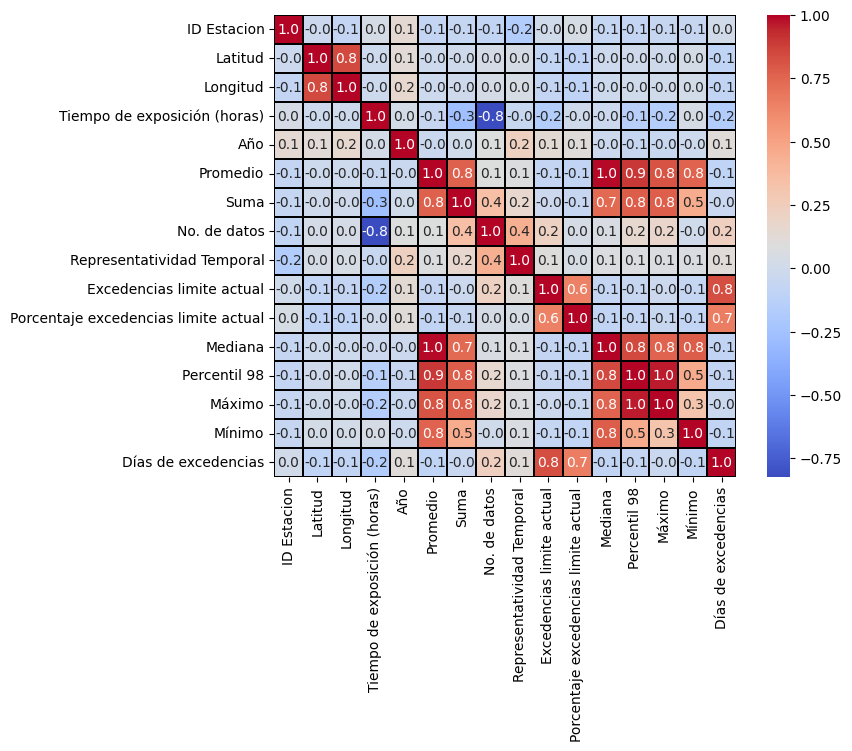

In [48]:
## Correlaciones, mapa de calor entre las columnas
corr = df_aire.select_dtypes(include= "number").corr()
corr
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    fmt= ".1f",
    square= True,
    linecolor = "Black",
    linewidths = 0.05,
    vmax = 1
    )

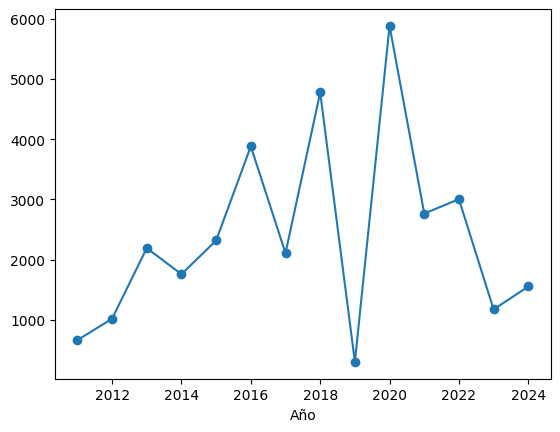

In [49]:
## Excedencias por año: Si estás evaluando calidad del aire, grafico de lineas
exc = df_aire.groupby('Año')['Días de excedencias'].sum()

exc.plot(marker='o')
plt.show()

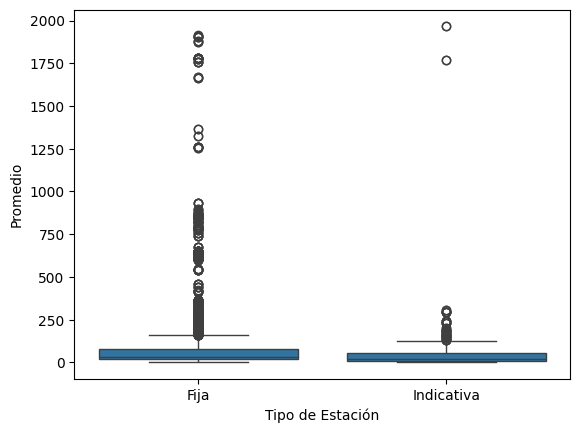

In [50]:
## Tipo de estación: Comparar estaciones fijas, móviles, etc.
sns.boxplot(data=df_aire,
            x='Tipo de Estación',
            y='Promedio')
plt.show()

<Axes: >

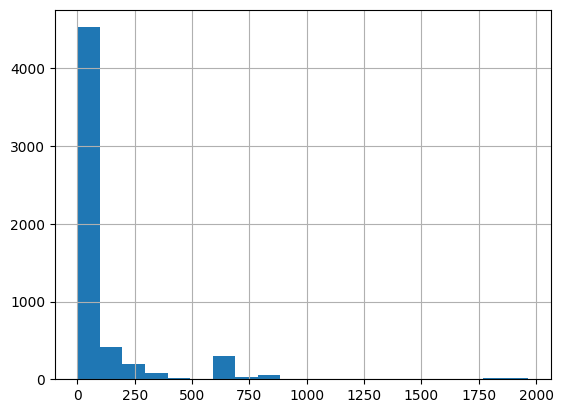

In [51]:
#Histograma con el promedio
df_aire["Promedio"].hist(bins=20)

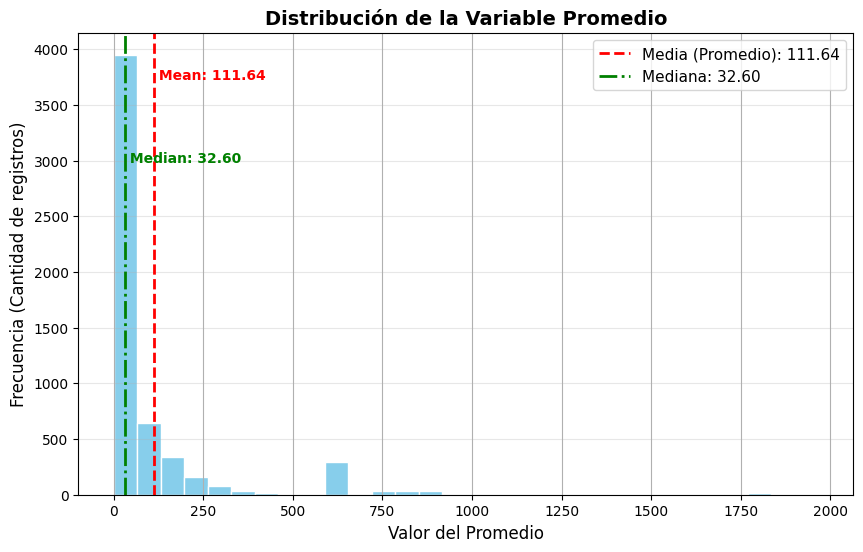

In [56]:
#Histograma para ver la media y la mediana
#Calculamos los valores estadísticos primero
media = df_aire["Promedio"].mean()
mediana = df_aire["Promedio"].median()

#Creamos el histograma
df_aire["Promedio"].hist(bins=30, color="skyblue", edgecolor="white", figsize=(10, 6))
plt.title("Distribución de la Variable Promedio", fontsize=14, fontweight='bold')
plt.xlabel("Valor del Promedio", fontsize=12)
plt.ylabel("Frecuencia (Cantidad de registros)", fontsize=12)

#Dibujamos las líneas verticales y les asignamos una etiqueta con su valor numérico
# El :.2f sirve para mostrar solo 2 decimales
plt.axvline(media, color="red", linestyle="--", linewidth=2, label=f"Media (Promedio): {media:.2f}")
plt.axvline(mediana, color="green", linestyle="-.", linewidth=2, label=f"Mediana: {mediana:.2f}")

# Pintar el texto numérico directamente sobre las líneas en la gráfica
# El 'plt.gca().get_ylim()[1]' detecta automáticamente qué tan alto es tu gráfico para poner el texto arriba
altura_texto = plt.gca().get_ylim()[1] * 0.9

plt.text(media, altura_texto, f' Mean: {media:.2f}', color='red', fontweight='bold')
plt.text(mediana, altura_texto * 0.8, f' Median: {mediana:.2f}', color='green', fontweight='bold')

# Activamos la leyenda y mostramos el gráfico
plt.legend(loc="upper right", fontsize=11)
plt.grid(axis='y', alpha=0.3) # Hace las líneas de fondo más suaves
plt.show()

In [57]:
#libreria necesaria
import plotly.express as px
#grafico de lineas
# Agrupar los datos reales por Año y Variable para obtener los promedios anuales
df_linea = df_aire.groupby(['Año', 'Variable'])['Promedio'].mean().reset_index()

fig1_line = px.line(
    df_linea,
    x='Año',
    y='Promedio',
    color='Variable',  # Genera una línea con un color diferente para cada variable real
    title='Promedio de Valor por Año y Variable (Evolución Temporal Real)',
    markers=True,      # Añade los puntos marcadores en cada año para facilitar la lectura
    template='plotly_dark'
)


fig1_line.update_layout(
    xaxis_title="Año",
    yaxis_title="Valor Promedio",
    title_font_size=16
)
# Mostrar el gráfico interactivo
fig1_line.show()

In [59]:
area_data = df_aire.groupby(['Año', 'Variable'])['Promedio'].mean().reset_index()

# gráfico de área con la totalidad de los datos
fig_area = px.area(
    area_data,
    x='Año',
    y='Promedio',
    color='Variable',  # Creará una capa de color distinta para cada variable real
    title='Promedio Anual por Variable (Tendencia Histórica Real)',
    line_group='Variable',
    template='plotly_dark'
)
fig_area.show()

In [60]:
#grafico de barras verticales del percentil 98 con las variables
datos_prueba = {
    'Variable': ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3'],
    'Percentil 98': [45.2, 85.6, 120.3, 35.1, 78.4]
}
df_filtered = pd.DataFrame(datos_prueba)

percentil_98_data = df_filtered.groupby('Variable')['Percentil 98'].mean().reset_index()
percentil_98_data = percentil_98_data.sort_values(by='Percentil 98', ascending=False)

fig_percentil_98 = px.bar(
    percentil_98_data,
    x='Variable',
    y='Percentil 98',
    color='Variable',
    title='Percentil 98 por Variable',
    labels={'Percentil 98': 'Valor del Percentil 98'},
    template='plotly_dark'
)

fig_percentil_98.update_traces(width=0.9)
fig_percentil_98.update_layout(
    bargap=0.3,
    title_font_size=16,
    xaxis_title="Variables Medidas",
    yaxis_title="Promedio del Percentil 98"
)

fig_percentil_98.show()

In [62]:
# Grafico de barras con las variables de contaminación, su concentración promedio y limites

pollution_limits = {'PM10': 50, 'PM2.5': 25, 'NO2': 200, 'SO2': 50, 'O3': 100}
gases_contaminantes = ['NO', 'NO2', 'SO2', 'SO2_TR', 'O3', 'CO']
material_particulado = ['PM10', 'PM2.5', 'PST']

def get_variable_type(variable):
    if variable in gases_contaminantes: return 'Gases Contaminantes'
    elif variable in material_particulado: return 'Material Particulado'
    return 'Otros'

datos_prueba = {
    'Variable': ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3'],
    'Unidades': ['ugm3', 'ugm3', 'ugm3', 'ugm3', 'ugm3'],
    'Promedio': [32.1, 58.4, 45.2, 12.1, 28.4]
}
df_filtered = pd.DataFrame(datos_prueba)

# --- CÓDIGO DEL GRÁFICO ---
df_filtered['Tipo de Variable'] = df_filtered['Variable'].apply(get_variable_type)
df_pollutants_for_limits = df_filtered[df_filtered['Tipo de Variable'].isin(['Gases Contaminantes', 'Material Particulado'])]
avg_concentration = df_pollutants_for_limits.groupby(['Variable', 'Unidades'])['Promedio'].mean().reset_index()

fig5 = px.bar(
    avg_concentration,
    x='Variable',
    y='Promedio',
    color='Promedio',
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Promedio de Concentración por Variable Contaminante con Límites de Referencia',
    template='plotly_dark'
)
fig5.update_traces(width=0.6)

for variable, limit in pollution_limits.items():
    if variable in avg_concentration['Variable'].values:
        unit = avg_concentration[avg_concentration['Variable'] == variable]['Unidades'].iloc[0]
        if unit in ['ugm3', 'ug/m3']:
            fig5.add_hline(
                y=limit,
                annotation_text=f'Límite {variable}: {limit} {unit}',
                annotation_position='top right',
                line_dash='dot',
                line_color='red',
                line_width=1.5
            )

fig5.update_layout(
    bargap=0.3, title_font_size=16,
    xaxis_title="Variable Contaminante", yaxis_title="Concentración Promedio"
)

fig5.show()

In [63]:
# mapa de calor para ver la correlación de las variables contaminantes y metrodologicas
meteorological_variables_list = ['VViento', 'TAire', 'HAire', 'P']
all_defined_contaminants = ['PM10', 'PM2.5', 'NO2', 'O3']

años = [2022, 2023, 2024, 2025]
variables = meteorological_variables_list + all_defined_contaminants

registros = []
for a in años:
    for v in variables:
        registros.append({'Año': a, 'Variable': v, 'Promedio': np.random.uniform(10, 100)})

df_for_correlation_matrix = pd.DataFrame(registros)

all_variables_in_data_for_corr = df_for_correlation_matrix['Variable'].unique().tolist()
actual_meteorological_vars_for_corr = [v for v in meteorological_variables_list if v in all_variables_in_data_for_corr]
actual_contaminant_vars_for_corr = [v for v in all_defined_contaminants if v in all_variables_in_data_for_corr]
correlation_columns_for_heatmap = actual_meteorological_vars_for_corr + actual_contaminant_vars_for_corr

if len(correlation_columns_for_heatmap) > 1:
    df_for_corr_pivot = df_for_correlation_matrix[df_for_correlation_matrix['Variable'].isin(correlation_columns_for_heatmap)].groupby(['Año', 'Variable'])['Promedio'].mean().reset_index()
    df_corr_matrix_data = df_for_corr_pivot.pivot_table(index='Año', columns='Variable', values='Promedio')

    if not df_corr_matrix_data.empty and len(df_corr_matrix_data.columns) > 1:
        corr_matrix = df_corr_matrix_data.corr()

        fig_heatmap = px.imshow(
            corr_matrix, text_auto=True, aspect="auto",
            title='Correlación entre Variables (Meteorológicas y Contaminantes)',
            color_continuous_scale='RdBu_r', labels=dict(color="Coef. Correlación"),
            width=800, height=700, template='plotly_dark'
        )
        fig_heatmap.show()

In [64]:
#Gráfico de barras para ver las variables y sus valores maximos registrados
datos_prueba = {
    'Variable': ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO'],
    'Máximo': [65.4, 110.2, 145.8, 38.9, 92.1, 5.4]
}
df_filtered = pd.DataFrame(datos_prueba)


max_value_per_variable = df_filtered.groupby('Variable')['Máximo'].max().reset_index()
max_value_per_variable = max_value_per_variable.sort_values(by='Máximo', ascending=False)

fig_max_var = px.bar(
    max_value_per_variable,
    x='Variable',
    y='Máximo',
    color='Variable',
    title='Máximo Valor Registrado por Variable',
    labels={'Máximo': 'Valor Máximo'},
    template='plotly_dark'
)

fig_max_var.update_traces(width=0.6)
fig_max_var.update_layout(
    bargap=0.3,
    title_font_size=16,
    xaxis_title="Variables",
    yaxis_title="Valor Máximo Registrado",
    showlegend=False
)

fig_max_var.show()

#Dashboard

In [65]:
# libreria para cargar el documento del drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
#instalación de librerias
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [68]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt

st.set_page_config(layout="wide", page_title="Dashboard Calidad del Aire 💨")

# --- Cargar y preparar los datos ---
@st.cache_data
def load_data():
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Proyecto final/Datesetlimpio_uso.csv')
    # Asegurarse de que las columnas de fecha sean datetime
    df['Fechas/horas del máximo'] = pd.to_datetime(df['Fechas/horas del máximo'], errors='coerce')
    df['Fechas/horas del mínimo'] = pd.to_datetime(df['Fechas/horas del mínimo'], errors='coerce')
    return df

df_aire = load_data()

# Definir límites de contaminación
pollution_limits = {
    'PM10': 50,  # ugm3, promedio anual
    'PM2.5': 25, # ugm3, promedio anual
    'NO2': 200,   # ugm3, promedio anual
    'SO2': 50,   # ugm3, promedio anual
    'O3': 100    # ugm3, promedio anual
}

# Categorías de variables para la tabla de límites y gráficos
gases_contaminantes = ['NO', 'NO2', 'SO2', 'SO2_TR', 'O3', 'CO']
material_particulado = ['PM10', 'PM2.5', 'PST']
meteorological_variables_list = ['VViento', 'DViento', 'TAire', 'TAire2', 'TAire10', 'PLiquida', 'P', 'HAire', 'HAire2', 'HAire10', 'RGlobal', 'RUVb']

# Todos los contaminantes para comparar y Top 5
all_defined_contaminants = gases_contaminantes + material_particulado

# Función para categorizar variables (for general use)
def get_variable_type(variable):
    if variable in gases_contaminantes:
        return 'Gases Contaminantes'
    elif variable in material_particulado:
        return 'Material Particulado'
    elif variable in meteorological_variables_list:
        return 'Variables Meteorológicas'
    return 'Otros'

# --- Título y Descripción ---
st.title('📊 Dashboard de Calidad del Aire en el Valle del Aburrá')
st.markdown('Explora los datos de calidad del aire y parámetros meteorológicos en el Valle del Aburrá. Utiliza los filtros para personalizar tu análisis.')

# --- Sidebar para Filtros ---
st.sidebar.header('⚙️ Opciones de Filtro')

# Filtro por Año
anio_options = ['Todas'] + sorted(df_aire['Año'].unique().tolist())
anio_seleccionado = st.sidebar.selectbox(
    'Selecciona el Año',
    options=anio_options,
    index=0
)

# Nuevo filtro 'Tipo de Variable' con 2 categorías
# Crear una columna 'Broad_Tipo_Variable' para el nuevo filtro
df_aire['Broad_Tipo_Variable'] = df_aire['Variable'].apply(lambda x: 'Variables Meteorológicas' if x in meteorological_variables_list else 'Contaminantes')
broad_tipo_variable_options = ['Todas'] + sorted(df_aire['Broad_Tipo_Variable'].unique().tolist())
broad_tipo_variable_seleccionada = st.sidebar.selectbox(
    'Selecciona el Tipo de Variable',
    options=broad_tipo_variable_options,
    index=0
)

# Filtro principal por Variable
variable_options = ['Todas'] + sorted(df_aire['Variable'].unique().tolist())
variable_seleccionada = st.sidebar.selectbox(
    'Selecciona la Variable',
    options=variable_options,
    index=0
)

# Filtro por Municipio
municipio_options = ['Todas'] + sorted(df_aire['Nombre del Municipio'].unique().tolist())
municipio_seleccionado = st.sidebar.selectbox(
    'Selecciona el Municipio',
    options=municipio_options,
    index=0
)

# --- Nueva columna con las categorías mapeadas ---
df_aire['Grupo Variable'] = df_aire['Variable'].apply(get_variable_type)

# --- Filtro por Grupo de Variable (Multiselect) ---
grupo_variable_options = sorted(df_aire['Grupo Variable'].unique().tolist())

grupo_variable_seleccionado = st.sidebar.multiselect(
    'Selecciona el Grupo de Variable',
    options=grupo_variable_options,
    default=grupo_variable_options  # Inicia con todas las categorías marcadas
)

# Filtro por Autoridad Ambiental (mantiene multiselect)
autoridad_seleccionada = st.sidebar.multiselect(
    'Selecciona la Autoridad Ambiental',
    options=sorted(df_aire['Autoridad Ambiental'].unique()),
    default=sorted(df_aire['Autoridad Ambiental'].unique())
)

# Filtro por Tipo de Estación (mantiene multiselect)
tipo_estacion_seleccionada = st.sidebar.multiselect(
    'Selecciona el Tipo de Estación',
    options=sorted(df_aire['Tipo de Estación'].unique()),
    default=sorted(df_aire['Tipo de Estación'].unique())
)

# Aplicar filtros
df_filtered = df_aire.copy()

if anio_seleccionado != 'Todas':
    df_filtered = df_filtered[df_filtered['Año'] == anio_seleccionado]

# Crear un DataFrame separado para el mapa de calor que esté filtrado por criterios generales pero no por una variable específica o tipo general
df_for_correlation_matrix = df_aire.copy()

if anio_seleccionado != 'Todas':
    df_for_correlation_matrix = df_for_correlation_matrix[df_for_correlation_matrix['Año'] == anio_seleccionado]

if municipio_seleccionado != 'Todas':
    df_for_correlation_matrix = df_for_correlation_matrix[df_for_correlation_matrix['Nombre del Municipio'] == municipio_seleccionado]

df_for_correlation_matrix = df_for_correlation_matrix[
    (df_for_correlation_matrix['Autoridad Ambiental'].isin(autoridad_seleccionada)) &
    (df_for_correlation_matrix['Tipo de Estación'].isin(tipo_estacion_seleccionada)) &
    (df_for_correlation_matrix['Grupo Variable'].isin(grupo_variable_seleccionado))
]

# Aplicar el nuevo filtro de tipo general al df_filtered principal para los otros gráficos
if broad_tipo_variable_seleccionada != 'Todas':
    df_filtered = df_filtered[df_filtered['Broad_Tipo_Variable'] == broad_tipo_variable_seleccionada]

if variable_seleccionada != 'Todas':
    df_filtered = df_filtered[df_filtered['Variable'] == variable_seleccionada]

if municipio_seleccionado != 'Todas':
    df_filtered = df_filtered[df_filtered['Nombre del Municipio'] == municipio_seleccionado]

df_filtered = df_filtered[
    (df_filtered['Autoridad Ambiental'].isin(autoridad_seleccionada)) &
    (df_filtered['Tipo de Estación'].isin(tipo_estacion_seleccionada)) &
    (df_filtered['Grupo Variable'].isin(grupo_variable_seleccionado))
]


# Mostrar mensaje si no hay datos
if df_filtered.empty:
    st.warning('⚠️ No hay datos que coincidan con los filtros seleccionados. Por favor, ajusta tus filtros.')
    st.stop()

# --- KPIs ---
st.subheader('📈 Indicadores Clave de Rendimiento (KPIs)')
col1, col2, col3, col4 = st.columns(4)

with col1:
    avg_promedio = df_filtered['Promedio'].mean()
    st.metric(label='Concentración Promedio 📊', value=f'{avg_promedio:.2f}')
with col2:
    max_promedio = df_filtered['Promedio'].max()
    st.metric(label='Pico Máximo Registrado ⬆️', value=f'{max_promedio:.2f}')
with col3:
    total_excedencias = df_filtered['Días de excedencias'].sum()
    st.metric(label='Total Días de Excedencias 🚫', value=f'{total_excedencias:,}')
with col4:
    num_registros = len(df_filtered)
    st.metric(label='Número de Registros 📝', value=f'{num_registros:,}')

st.markdown('---')

# --- Gráficos ---
st.subheader('📊 Visualizaciones de Datos')

# Usar st.tabs para organizar los gráficos
tab1, tab2, tab3, tab4, tab5 = st.tabs(["Histórico y Tendencias", "Comportamiento de Datos", "Mapas y Límites Legales", "Análisis Geográfico", "Tablas de Resumen"])

with tab1:
    st.markdown('### Evolución Temporal del Promedio por Variable')
   # Aplicar el nuevo filtro de tipo general al df_filtered principal para los otros gráficos
    fig1_line = px.line(
        df_filtered.groupby(['Año', 'Variable'])['Promedio'].mean().reset_index(),
        x='Año',
        y='Promedio',
        color='Variable',
        title='Promedio de Valor por Año y Variable',
        markers=True,
        template='plotly_dark'
    )
    st.plotly_chart(fig1_line, use_container_width=True)

    st.markdown('### Días de Excedencias por Año')
    excedencias_anual = df_filtered.groupby('Año')['Días de excedencias'].sum().reset_index()
    fig6 = px.line(
        excedencias_anual,
        x='Año',
        y='Días de excedencias',
        title='Total de Días de Excedencias por Año',
        markers=True,
        template='plotly_dark'
    )
    st.plotly_chart(fig6, use_container_width=True)

    st.markdown('### Tendencia Anual Promedio por Variable (Area Chart)')
    area_data = df_filtered.groupby(['Año', 'Variable'])['Promedio'].mean().reset_index()
    fig_area = px.area(
        area_data,
        x='Año',
        y='Promedio',
        color='Variable',
        title='Promedio Anual por Variable (Tendencia)',
        line_group='Variable',
        template='plotly_dark'
    )
    st.plotly_chart(fig_area, use_container_width=True)

with tab2:
    st.markdown('### Promedio de Valor por Municipio')
    fig2 = px.bar(
        df_filtered.groupby('Nombre del Municipio')['Promedio'].mean().reset_index().sort_values(by='Promedio', ascending=False),
        x='Nombre del Municipio',
        y='Promedio',
        color='Nombre del Municipio',
        title='Promedio de Valor por Municipio',
        labels={'Promedio': 'Promedio del Valor'},
        template='plotly_dark'
    )
    # Configuración del grosor de las barras (0.5 funciona excelente para nombres de municipios)
    fig2.update_traces(width=0.8)
    #  Ajustes extras de diseño (Mejora la lectura si hay muchos municipios)
    fig2.update_layout(
        bargap=0.3,
        title_font_size=16,
        xaxis_title="Municipio",
        yaxis_title="Valor Promedio de Contaminación",
        showlegend=False  # Ocultamos la leyenda lateral porque el nombre ya sale en el eje X (así ganas espacio para el gráfico)
    )

    st.plotly_chart(fig2, use_container_width=True)

    st.markdown('### Percentil 98 por Variable')
    percentil_98_data = df_filtered.groupby('Variable')['Percentil 98'].mean().reset_index().sort_values(by='Percentil 98', ascending=False)
    fig_percentil_98 = px.bar(
        percentil_98_data,
        x='Variable',
        y='Percentil 98',
        color='Variable',
        title='Percentil 98 por Variable',
        labels={'Percentil 98': 'Valor del Percentil 98'},
        template='plotly_dark'
    )
    #  Configuración del grosor de las barras (0.4 las hace lucir más delgadas y estéticas)
    fig_percentil_98.update_traces(width=0.9)

    # Opcional: Ajustar el espaciado general del diseño para que se vea más limpio
    fig_percentil_98.update_layout(
        bargap=0.3,
        title_font_size=16,
        xaxis_title="Variables Medidas",
        yaxis_title="Promedio del Percentil 98"

    )
    st.plotly_chart(fig_percentil_98, use_container_width=True)

    st.markdown('### Dispersión: Promedio vs. Representatividad Temporal por Variable')
    if not df_filtered.empty:
        fig_scatter_representativity = px.scatter(
            df_filtered,
            x='Representatividad Temporal',
            y='Promedio',
            color='Variable',
            hover_name='Variable',
            title='Relación entre el Promedio y la Representatividad Temporal por Variable',
            labels={'Representatividad Temporal': 'Representatividad Temporal (%)', 'Promedio': 'Valor Promedio'},
            template='plotly_dark'
        )
        st.plotly_chart(fig_scatter_representativity, use_container_width=True)
    else:
        st.info("No hay datos suficientes para generar el gráfico de dispersión de Promedio vs. Representatividad Temporal.")

    st.markdown('### Histograma de la Variable Promedio con Media y Mediana')
     # Calculamos los valores estadísticos para la leyenda
    if not df_filtered.empty:
      media = df_filtered["Promedio"].mean()
      mediana = df_filtered["Promedio"].median()
      # Creamos el Histograma usando Plotly Express (Igual al formato de tus otros gráficos)
      fig_hist = px.histogram(
          df_filtered,
          x="Promedio",
          nbins=40,
          title="Distribución de la Variable Promedio",
          labels={'Promedio': 'Valor del Promedio', 'count': 'Frecuencia'},
          template='plotly_dark'  # Activa el fondo oscuro idéntico al de dispersión
        )

      # Cambiamos el color de las barras y el tamaño (grosor/separación)
      # Usamos un color verde vibrante o el de tu preferencia, y 'bargap' para separarlas de forma estética
      fig_hist.update_traces(
          marker_color='#00FA9A',   # Verde menta/neón que resalta excelente en modo oscuro
          marker_line_color='white',
          marker_line_width=0.5
          )
      #  Dibujamos las líneas verticales de Media y Mediana
      # En Plotly se usan 'add_vline' que quedan perfectamente integradas
      fig_hist.add_vline(
          x=media,
          line_dash="dash",
          line_color="red",
          line_width=2.5,
          annotation_text=f"Media: {media:.2f}",
          annotation_position="top right",
          annotation_font_color="red"
      )

      fig_hist.add_vline(
          x=mediana,
          line_dash="dashdot",
          line_color="orange",  # Cambiado a naranja para que resalte sobre el fondo y las barras verdes
          line_width=2.5,
          annotation_text=f"Mediana: {mediana:.2f}",
          annotation_position="top left",
          annotation_font_color="orange"
    )
      # Ajustes finales de diseño para unificar el tamaño y las tipografías
      fig_hist.update_layout(
          bargap=0.15,
          title_font_size=16,
          xaxis_title="Valor del Promedio",
          yaxis_title="Frecuencia (Cantidad de registros)",
          showlegend=False
    )
      #  Renderizar en Streamlit con ancho completo
      st.plotly_chart(fig_hist, use_container_width=True)
    else:
        st.info("No hay datos suficientes para generar el histograma de la variable Promedio.")

with tab3:
    st.markdown('### Ubicación de las Estaciones de Monitoreo')
    if 'Latitud' in df_filtered.columns and 'Longitud' in df_filtered.columns:

        df_filtered['Tipo de Variable'] = df_filtered['Variable'].apply(get_variable_type)
        map_data = df_filtered[['Estación', 'Latitud', 'Longitud', 'Variable', 'Promedio', 'Tipo de Estación', 'Tipo de Variable']].drop_duplicates(subset=['Estación', 'Latitud', 'Longitud'])
        if not map_data.empty:
            st.map(map_data.rename(columns={'Latitud': 'lat', 'Longitud': 'lon'}))
        else:
            st.warning('No hay datos de ubicación para las estaciones seleccionadas.')
    else:
        st.warning('Las columnas de latitud y longitud no están disponibles en el dataset.')

    st.markdown('###Concentración Promedio por Variable con Límites de Contaminación')

    df_filtered['Tipo de Variable'] = df_filtered['Variable'].apply(get_variable_type)

    df_pollutants_for_limits = df_filtered[df_filtered['Tipo de Variable'].isin(['Gases Contaminantes', 'Material Particulado'])]
    avg_concentration = df_pollutants_for_limits.groupby(['Variable', 'Unidades'])['Promedio'].mean().reset_index()

    fig5 = px.bar(
        avg_concentration,
        x='Variable',
        y='Promedio',
        color='Promedio',
        color_continuous_scale=px.colors.sequential.Plasma,
        title='Promedio de Concentración por Variable Contaminante con Límites de Referencia',
        template='plotly_dark' # Changed to plotly_dark
    )
    #  Configurar el grosor de las barras para mantener tu formato estilizado
    fig5.update_traces(width=0.6)
    #  Dibujar las líneas de límite alternando las posiciones para que NO se monten
    # Usaremos un contador para enviar una línea a la derecha y la siguiente a la izquierda
    contador = 0
    for variable, limit in pollution_limits.items():
        if variable in avg_concentration['Variable'].values:
            unit = avg_concentration[avg_concentration['Variable'] == variable]['Unidades'].iloc[0]
            if unit == 'ugm3' or unit == 'ug/m3': # Asegurarse que la unidad coincida

                # TRUCO: Si el contador es par va a la derecha, si es impar va a la izquierda
                posicion_texto = 'top right' if contador % 2 == 0 else 'top left'
                fig5.add_hline(y=limit,
                               annotation_text=f'Límite {variable}: {limit} {unit}',
                               annotation_position='top right',
                               line_dash='dot',
                               line_color='red',
                               line_width=1.5
                               )
                contador += 1
    # 4. Ajustes generales de diseño y espaciado
    fig5.update_layout(
        bargap=0.3,
        title_font_size=16,
        xaxis_title="Variable Contaminante",
        yaxis_title="Concentración Promedio",
        coloraxis_colorbar=dict(title="Promedio")
      )
    st.plotly_chart(fig5, use_container_width=True)

with tab4:
    st.markdown('### Mapa de Calor de Correlación entre Variables Meteorológicas y Contaminantes')

    # Obtener todas las variables únicas presentes en los datos filtrados para la matriz de correlación
    all_variables_in_data_for_corr = df_for_correlation_matrix['Variable'].unique().tolist()
    # Filtrar por las variables presentes en los datos de correlación que sean meteorológicas o contaminantes
    actual_meteorological_vars_for_corr = [v for v in meteorological_variables_list if v in all_variables_in_data_for_corr]
    actual_contaminant_vars_for_corr = [v for v in all_defined_contaminants if v in all_variables_in_data_for_corr]

    # Combinar estos para la matriz de correlación, utilizando 'Promedio' como el valor
    correlation_columns_for_heatmap = actual_meteorological_vars_for_corr + actual_contaminant_vars_for_corr

    if len(correlation_columns_for_heatmap) > 1:
        df_for_corr_pivot = df_for_correlation_matrix[df_for_correlation_matrix['Variable'].isin(correlation_columns_for_heatmap)].groupby(['Año', 'Variable'])['Promedio'].mean().reset_index()
        df_corr_matrix_data = df_for_corr_pivot.pivot_table(index='Año', columns='Variable', values='Promedio')

        if not df_corr_matrix_data.empty and len(df_corr_matrix_data.columns) > 1:
            corr_matrix = df_corr_matrix_data.corr()
            fig_heatmap = px.imshow(corr_matrix,
                                     text_auto=True,
                                     aspect="auto",
                                     title='Correlación entre Variables (Meteorológicas y Contaminantes)',
                                     color_continuous_scale='RdBu_r',
                                     labels=dict(color="Coef. Correlación"),
                                     width=900,
                                     height=800,
                                     template='plotly_dark')
            st.plotly_chart(fig_heatmap, use_container_width=True)
        else:
            st.info("No hay suficientes variables o datos para calcular la correlación en el mapa de calor con los filtros actuales.")
    else:
        st.info("No hay suficientes variables (meteorológicas o contaminantes) en los datos filtrados para generar un mapa de calor de correlación.")

    st.markdown('### Distribución de Contaminación por Municipio ')
      # Filtramos para quedarnos solo con los 10 municipios más relevantes (opcional, para que no se amontone)
    if not df_filtered.empty:
      stats_municipio = df_filtered.groupby('Nombre del Municipio')['Promedio'].agg(['mean', 'std']).dropna().reset_index()
      stats_municipio = stats_municipio.sort_values(by='mean', ascending=False).head(10)
        #  Creamos el BOXPLOT con Plotly Express
      if not stats_municipio.empty:
        fig_error_bar = px.bar(
            stats_municipio,
            x='Nombre del Municipio',
            y='mean',
            error_y='std',  # Le da un color llamativo y diferente a cada caja
            title='Promedio de Contaminación por Municipio con su Desviación Estándar',
            labels={'mean': 'Valor de Contaminación', 'Nombre del Municipio': 'Municipio'},
            template='plotly_dark'          # Aplica el fondo oscuro exacto de tu imagen
         )

        #  Estilizado de las líneas para que TODO sea visible (adiós al negro invisible)
        fig_error_bar.update_traces(
            marker_color='seagreen',         # Muestra los puntos atípicos (outliers) flotando
            width=0.4,                 # Caja estándar
            error_y=dict(
                thickness=2,          # Grosor de la línea de la antena
                color='white',        # Vuelve las antenas blancas para que resalten en la oscuridad
                width=6  # Hace los bordes de las cajas más gruesos y definidos
            )
        )
        #  Ajustes del diseño general
        fig_error_bar.update_layout(
            bargap=0.3,                    # Controla el espacio entre cada caja (el "grosor")
            title_font_size=16,
            xaxis_title="Municipio",
            yaxis_title="Promedio de Contaminación",
            showlegend=False               # Ocultamos la leyenda porque el nombre ya se lee abajo en el eje X
          )
        # Renderizar en Streamlit
        st.plotly_chart(fig_error_bar, use_container_width=True)
      else:
            st.info("No hay datos suficientes para generar el gráfico de barras de error con la desviación estándar para los municipios.")
    else:
        st.info("No hay datos suficientes para generar el gráfico de barras de error con la desviación estándar para los municipios.")

with tab5:
    st.markdown('### Top 5 Contaminantes del Aire más Representativos (Promedio)')
    # Filtrar por todas las variables consideradas 'contaminantes'
    all_contaminant_variables_for_top5 = gases_contaminantes + material_particulado
    df_pollutants_top5 = df_filtered[df_filtered['Variable'].isin(all_contaminant_variables_for_top5)]
    if not df_pollutants_top5.empty:
        top_5_pollutants = df_pollutants_top5.groupby('Variable')['Promedio'].mean().sort_values(ascending=False).head(5)
        st.dataframe(top_5_pollutants.reset_index().rename(columns={'Promedio': 'Promedio Anual'}))
    else:
        st.info("No hay datos de variables contaminantes para la selección actual para calcular el Top 5.")

    st.markdown('### Comparación Anual de Contaminantes con Límites de Referencia')
    # Filtrar por todas las variables consideradas 'contaminantes'
    df_contaminants_annual_comparison = df_filtered[df_filtered['Variable'].isin(all_defined_contaminants)]
    if not df_contaminants_annual_comparison.empty:
        df_comparison_annual = df_contaminants_annual_comparison.groupby(['Año', 'Variable'])['Promedio'].mean().reset_index()
        df_comparison_annual['Límite Sugerido'] = df_comparison_annual['Variable'].map(pollution_limits)

        # Combinar con las unidades del df_aire original (o df_filtered si está disponible)
        variable_units_map = df_aire[['Variable', 'Unidades']].drop_duplicates().set_index('Variable')['Unidades'].to_dict()
        df_comparison_annual['Unidades'] = df_comparison_annual['Variable'].map(variable_units_map)

        # Asegurar que solo mostremos las variables relevantes para la comparación con los límites
        st.dataframe(df_comparison_annual[['Año', 'Variable', 'Promedio', 'Límite Sugerido', 'Unidades']].dropna(subset=['Límite Sugerido']).sort_values(by=['Año', 'Variable']))
    else:
        st.info("No hay datos de variables contaminantes para generar la tabla de comparación anual.")

    st.markdown('### Máximo Valor Registrado por Variable')
    max_value_per_variable = (df_filtered.groupby('Variable')['Máximo'].max().reset_index().sort_values(by='Máximo', ascending=False))
    fig_max_var = px.bar(
        max_value_per_variable,
        x='Variable',
        y='Máximo',
        color='Variable',
        title='Máximo Valor Registrado por Variable',
        labels={'Máximo': 'Valor Máximo'},
        template='plotly_dark' # Changed to plotly_dark
    )
    #  Configuración del grosor de las barras (0.4 las deja estilizadas y modernas)
    fig_max_var.update_traces(width=0.6)
    # Ajustes de diseño y espaciado
    fig_max_var.update_layout(
        bargap=0.3,
        title_font_size=16,
        xaxis_title="Variables",
        yaxis_title="Valor Máximo Registrado",
        showlegend=False  # Ocultamos la leyenda para limpiar la pantalla, ya que el nombre está en el eje X
    )
    st.plotly_chart(fig_max_var, use_container_width=True)

    # --- Tabla de Datos ---
    st.markdown('---')
    with st.expander("Ver Datos Filtrados"): # Usamos un expander para la tabla
        st.dataframe(df_filtered)

Writing app.py


In [72]:
# sirve para que la aplicacion streamilt este en segundo plano asegurandose que el servidor
# siempre este encendido
!streamlit run app.py &>/content/logs.txt &

import time
import urllib.request

# Espera hasta que el servidor de Streamlit esté activo
while True:
    try:
        urllib.request.urlopen('http://localhost:8501')
        break
    except urllib.error.URLError:
        time.sleep(1)

print("Streamlit app is running.")

Streamlit app is running.


In [70]:
# me da el valor de la ip
!wget -qO- ipv4.icanhazip.com

34.150.245.178


In [ ]:
# me da la url a usar
!lt --port 8501

your url is: https://forty-rocks-sneeze.loca.lt
